# Dark Store Demand Forecasting: Exploratory Data Analysis (EDA)

This notebook analyzes the processed Instacart daily demand dataset (`data/processed/daily_demand.parquet`) and raw order distributions.

### Objectives:
1. **Overall Demand Trend**: Visualize overall daily demand trajectories over time.
2. **Seasonality Analysis**: Heatmaps across Day-of-Week and Hour-of-Day order patterns.
3. **Category Volatility**: Top 10 most volatile departments by Coefficient of Variation ($CV = \sigma / \mu$).
4. **Reorder Distribution**: Distribution of product and department repeat purchase rates.
5. **Executive Summary**: 3-4 key operational takeaways for non-technical stakeholders.

In [ ]:
import sys
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import RAW_DATA_DIR, PROCESSED_DATA_DIR
from src.data_loader import load_raw_data, load_and_process_demand

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11 

## 1. Data Loading

In [12]:
parquet_path = PROCESSED_DATA_DIR / "daily_demand.parquet"

if not parquet_path.exists():
    print(f"Parquet file not found at {parquet_path}. Generating from raw data...")
    daily_demand_df = load_and_process_demand(data_dir=RAW_DATA_DIR, output_file=parquet_path)
else:
    print(f"Loading daily demand dataset from {parquet_path}...")
    daily_demand_df = pd.read_parquet(parquet_path)

print(f"Daily Demand Dataset Shape: {daily_demand_df.shape}")
daily_demand_df.head(10)

Loading daily demand dataset from C:\Users\ankur\Desktop\mlops prac\dark store demand\data\processed\daily_demand.parquet...
Daily Demand Dataset Shape: (53802, 6)


,date,department,order_dow,demand,unique_orders,unique_users
0,2024-01-01,alcohol,0,1598,1033,1021
1,2024-01-01,alcohol,1,1647,939,927
2,2024-01-01,alcohol,2,1697,942,923
3,2024-01-01,alcohol,3,1837,978,968
4,2024-01-01,alcohol,4,2044,1026,1010
5,2024-01-01,alcohol,5,2300,1218,1196
6,2024-01-01,alcohol,6,1866,1126,1112
7,2024-01-01,babies,0,4324,1746,1739
8,2024-01-01,babies,1,4073,1610,1601
9,2024-01-01,babies,2,3015,1228,1216


## 2. Overall Demand Trend Over Time

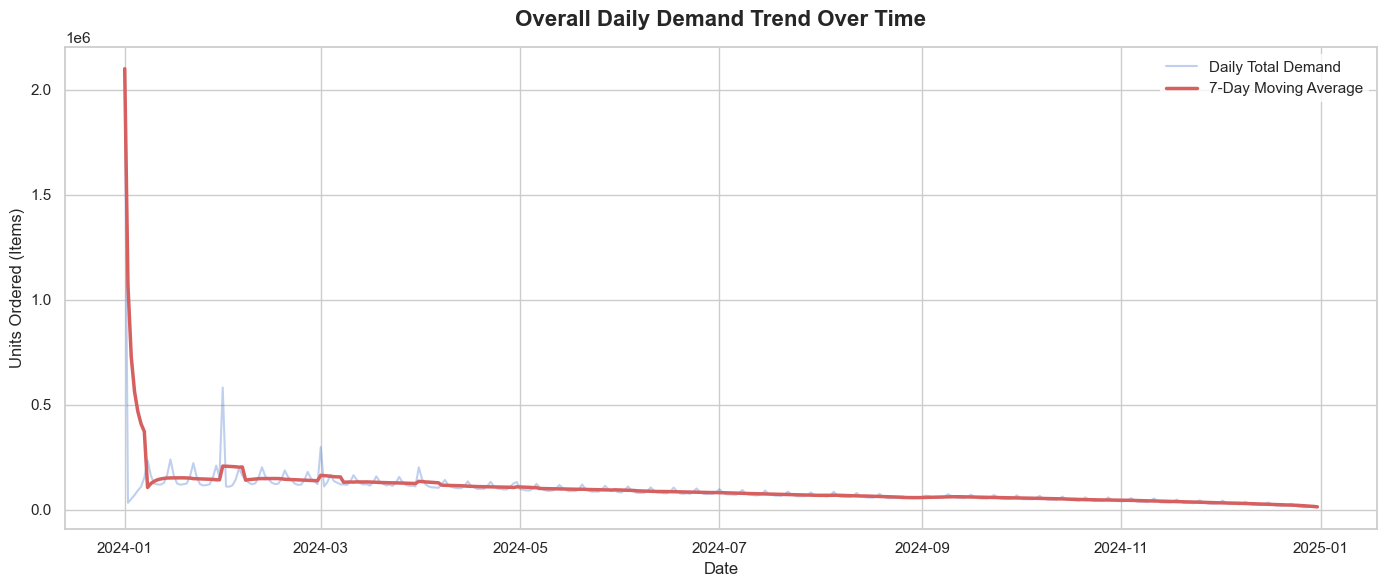

In [16]:
# Aggregate daily total item demand
total_daily = (
    daily_demand_df.groupby("date")["demand"]
    .sum()
    .reset_index()
    .sort_values("date")
)

# 7-day rolling average for trend smoothing
total_daily["7d_rolling_avg"] = total_daily["demand"].rolling(window=7, min_periods=1).mean()

plt.figure(figsize=(14, 6))
plt.plot(total_daily["date"], total_daily["demand"], alpha=0.35, color="b", label="Daily Total Demand")
plt.plot(total_daily["date"], total_daily["7d_rolling_avg"], color="r", linewidth=2.5, label="7-Day Moving Average")

plt.title("Overall Daily Demand Trend Over Time", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Units Ordered (Items)", fontsize=12)
plt.legend(frameon=True, facecolor="white", edgecolor="none")
plt.tight_layout()
plt.show()

## 3. Demand Seasonality (Day-of-Week & Hour-of-Day Heatmaps)

2026-08-13 19:50:54,267 - INFO - Loading raw CSV datasets from 'C:\Users\ankur\Desktop\mlops prac\dark store demand\data\raw'...
2026-08-13 19:51:00,934 - INFO - Loaded total 33,819,106 order-product items and 3,421,083 orders.
2026-08-13 19:51:01,789 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
C:\Users\ankur\AppData\Local\Temp\ipykernel_21096\2139919860.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dow_counts.index, y=dow_counts.values, palette="Blues_d", ax=axes[1])
2026-08-13 19:51:01,799 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before

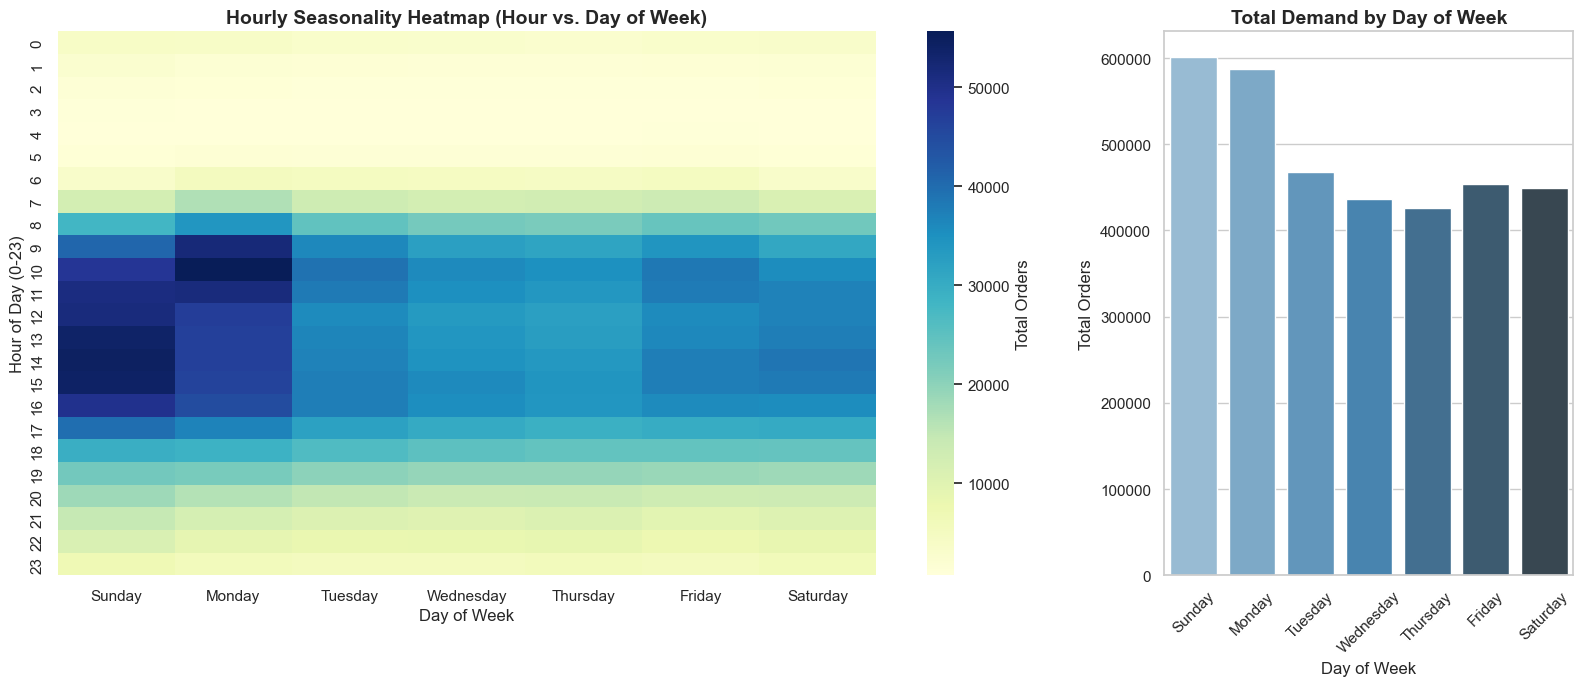

In [ ]:
# Load raw orders metadata for hour x day seasonality heatmap
raw_data = load_raw_data(data_dir=RAW_DATA_DIR)
orders_df = raw_data["orders"]

dow_map = {0: "Sunday", 1: "Monday", 2: "Tuesday", 3: "Wednesday", 4: "Thursday", 5: "Friday", 6: "Saturday"}
orders_df["day_name"] = orders_df["order_dow"].map(dow_map)
day_order = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]

# Pivot matrix: Hour of Day vs. Day of Week
seasonality_pivot = orders_df.pivot_table(
    index="order_hour_of_day",
    columns="day_name",
    values="order_id",
    aggfunc="count"
)[day_order]

fig, axes = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={"width_ratios": [2.5, 1]})

# Heatmap
sns.heatmap(seasonality_pivot, cmap="YlGnBu", annot=False, cbar_kws={"label": "Total Orders"}, ax=axes[0])
axes[0].set_title("Hourly Seasonality Heatmap (Hour vs. Day of Week)", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Day of Week", fontsize=12)
axes[0].set_ylabel("Hour of Day (0-23)", fontsize=12)

# Day of week bar chart
dow_counts = orders_df.groupby("day_name")["order_id"].count().reindex(day_order)
sns.barplot(x=dow_counts.index, y=dow_counts.values, palette="Blues_d", ax=axes[1])
axes[1].set_title("Total Demand by Day of Week", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Day of Week", fontsize=12)
axes[1].set_ylabel("Total Orders", fontsize=12)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 4. Top 10 Most Volatile Departments (Coefficient of Variation)

C:\Users\ankur\AppData\Local\Temp\ipykernel_21096\783447416.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  daily_demand_df.groupby("department")["demand"]
C:\Users\ankur\AppData\Local\Temp\ipykernel_21096\783447416.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top10_volatile, x="cv", y="department", palette="Reds_r")


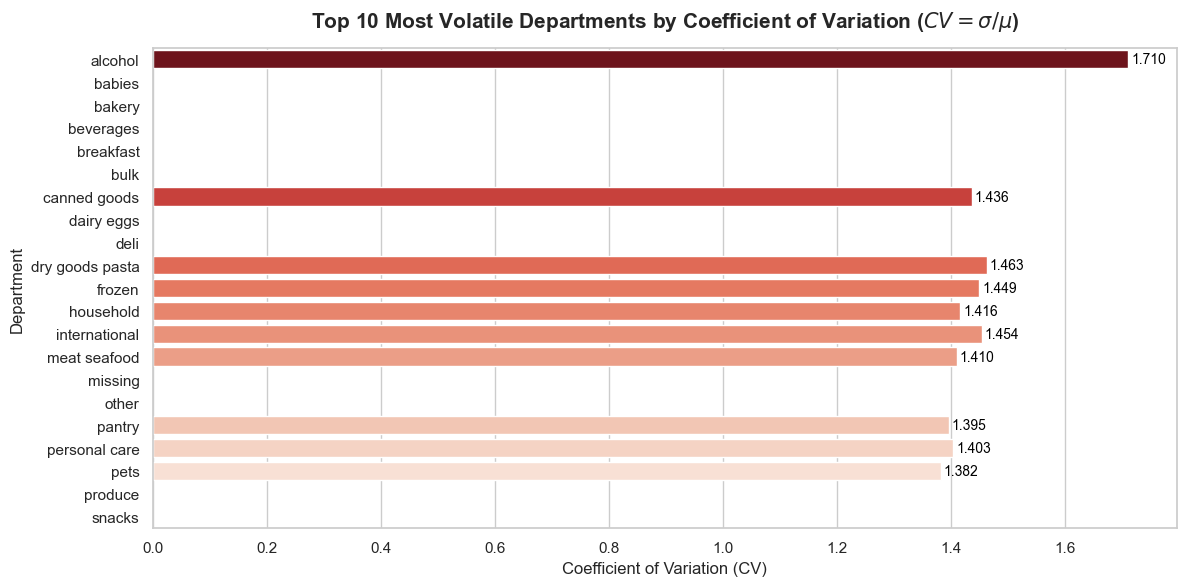

,department,mean_demand,std_demand,cv
0,alcohol,62.175644,106.336805,1.710265
9,dry goods pasta,353.372365,516.875605,1.462694
12,international,109.740437,159.556213,1.453942
10,frozen,912.122560,1322.029537,1.449399
6,canned goods,435.151054,624.974257,1.436224
11,household,302.362217,427.995843,1.415507
13,meat seafood,288.539422,406.863044,1.410078
17,personal care,182.940281,256.729738,1.403353
16,pantry,763.785714,1065.732673,1.395329
18,pets,39.898907,55.127352,1.381676


In [28]:
# Compute Mean (μ), Standard Deviation (σ), and Coefficient of Variation (CV = σ / μ)
dept_stats = (
    daily_demand_df.groupby("department")["demand"]
    .agg(mean_demand="mean", std_demand="std")
    .reset_index()
)
dept_stats["cv"] = dept_stats["std_demand"] / dept_stats["mean_demand"]
top10_volatile = dept_stats.sort_values("cv", ascending=False).head(10)

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=top10_volatile, x="cv", y="department", palette="Reds_r")
plt.title("Top 10 Most Volatile Departments by Coefficient of Variation ($CV = \sigma / \mu$)", fontsize=15, fontweight="bold", pad=15)
plt.xlabel("Coefficient of Variation (CV)", fontsize=12)
plt.ylabel("Department", fontsize=12)

for p in ax.patches:
    width = p.get_width()
    ax.annotate(f"{width:.3f}", (width + 0.005, p.get_y() + p.get_height() / 2.),
                ha='left', va='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()

top10_volatile

## 5. Reorder Rate Distribution

C:\Users\ankur\AppData\Local\Temp\ipykernel_21096\2684478325.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("department")["reordered"]
C:\Users\ankur\AppData\Local\Temp\ipykernel_21096\2684478325.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dept_reorder.head(10), x="reordered", y="department", palette="Greens_r", ax=axes[1])


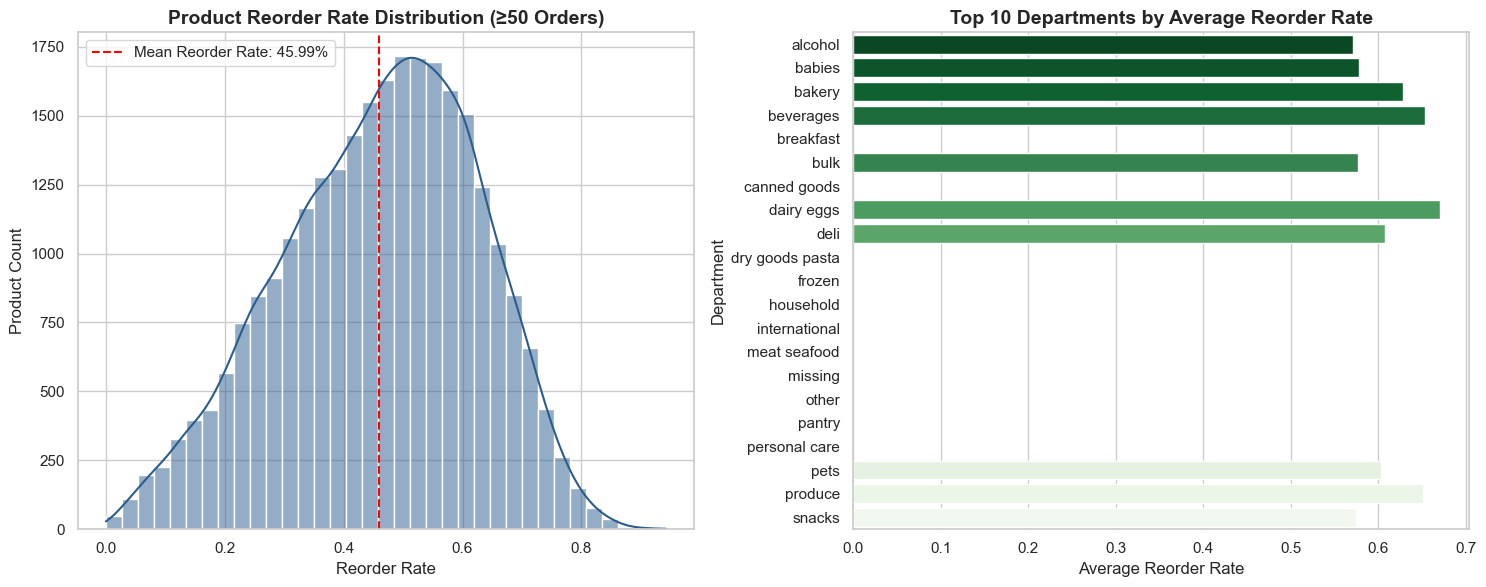

In [29]:
order_prods = raw_data["order_products"]
prod_reorders = (
    order_prods.groupby("product_id")["reordered"]
    .agg(total_orders="count", reorder_rate="mean")
    .reset_index()
)
stable_prods = prod_reorders[prod_reorders["total_orders"] >= 50]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Reorder Rate Distribution
sns.histplot(stable_prods["reorder_rate"], kde=True, bins=35, color="#2b5c8f", ax=axes[0])
mean_rr = stable_prods["reorder_rate"].mean()
axes[0].axvline(mean_rr, color="red", linestyle="--", label=f"Mean Reorder Rate: {mean_rr:.2%}")
axes[0].set_title("Product Reorder Rate Distribution (≥50 Orders)", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Reorder Rate", fontsize=12)
axes[0].set_ylabel("Product Count", fontsize=12)
axes[0].legend()

# Plot 2: Top Departments by Reorder Rate
prod_meta = raw_data["products"].merge(raw_data["departments"], on="department_id", how="left")
dept_reorder = (
    order_prods.merge(prod_meta, on="product_id", how="left")
    .groupby("department")["reordered"]
    .mean()
    .reset_index()
    .sort_values("reordered", ascending=False)
)

sns.barplot(data=dept_reorder.head(10), x="reordered", y="department", palette="Greens_r", ax=axes[1])
axes[1].set_title("Top 10 Departments by Average Reorder Rate", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Average Reorder Rate", fontsize=12)
axes[1].set_ylabel("Department", fontsize=12)

plt.tight_layout()
plt.show()

## 6. Executive Summary & Key Business Takeaways

### Plain English Findings for Non-Technical Stakeholders & Dark Store Operations:

1. **Peak Demand: Sunday & Monday, Late Morning Through Afternoon**:
   - Ordering concentrates heavily on **Sunday and Monday, roughly 9:00 AM-4:00 PM**, with the single busiest window being Monday 10-11 AM.
   - Combined Sunday/Monday volume runs about **33% higher** than the Tuesday-Saturday average (~594K vs. ~447K orders/day).
   - *Actionable Takeaway*: Scale up picking and delivery staffing for Sunday/Monday daytime shifts to meet guaranteed delivery windows.

2. **Staple Products Drive Customer Retention (Dairy & Produce)**:
   - Dairy/Eggs has the highest reorder rate of any department (~67%). Produce and Beverages follow closely at around **65%**.
   - *Actionable Takeaway*: Maintain high baseline safety stock for top staple SKUs, out-of-stock events here carry the highest churn risk.

3. **High Supply Chain Volatility in Alcohol, Dry Goods/Pasta, International, and Frozen**:
   - These departments show the highest day-to-day demand variance relative to their own average, with Coefficient of Variation (CV) values between **1.4 and 1.7** well above the more stable staple categories.
   - *Actionable Takeaway*: Apply dynamic reorder-point models rather than fixed safety stock thresholds for these volatile, less-predictable categories.

4. **Predictable Weekly Cyclical Patterns**:
   - Daily order volume shows strong, consistent day-of-week periodicity, visible in both the heatmap and the 7-day rolling average.
   - *Actionable Takeaway*: Gradient-boosted models (e.g., XGBoost) using engineered 7-day lag/rolling features, alongside SARIMA and Prophet baselines, are well suited to capture this weekly cycle for automated replenishment forecasting.
